In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel('Sample - Superstore-2026.xlsx')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


1. Load the Orders sheet with pandas and report the number of rows, columns, and unique Order IDs.
   | Metric               | Result |
| -------------------- | -----: |
| **Rows**             | 10,194 |
| **Columns**          |     21 |
| **Unique Order IDs** |  5,111 |


In [4]:
df.shape    

(10194, 21)

In [5]:
df['Order ID'].nunique()   

5111

2. Inspect the Orders dataset for missing values and identify which columns contain nulls.

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [51]:
df = df.rename(columns={'Country/Region' : 'Country', 'State/Province' : 'State'})

In [54]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

3. Calculate total Sales, total Profit, and total Quantity sold using pandas

In [7]:
total_sales = df["Sales"].sum().round(2)
total_profit = df["Profit"].sum().round(2)
total_quantity = df["Quantity"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)

Total Sales: 2326534.35
Total Profit: 292296.81
Total Quantity Sold: 38654


4. Find the minimum, maximum, mean, and median Sales values for individual order lines.

In [8]:
minimum_sales = df["Sales"].min()
maximum_sales = df["Sales"].max()
mean_sales = df["Sales"].mean()
median_sales = df["Sales"].median()

print("Minimum Sales:", minimum_sales)
print("Maximum Sales:", maximum_sales)
print("Mean Sales:", mean_sales)
print("Median Sales:", median_sales)

Minimum Sales: 0.44399999999999995
Maximum Sales: 22638.48
Mean Sales: 228.22585386501862
Median Sales: 53.91


5. Count how many unique customers are present in the Orders dataset.

In [9]:
df['Customer Name'].nunique()

800

In [10]:
# df['Customer Name'].unique()

6. Calculate total Sales and Profit for each Category.

In [11]:
df.groupby('Category')[['Sales', 'Profit']].sum()

,Sales,Profit
Category,,
Furniture,754747.7613,19729.9956
Office Supplies,731893.3140,126023.4434
Technology,839893.2790,146543.3756


7. Calculate total Quantity sold for each Sub-Category and sort the results from highest to lowest.

In [12]:
df.groupby('Sub-Category')['Quantity'].sum().sort_values(ascending=False).reset_index()

,Sub-Category,Quantity
0,Binders,6071
1,Paper,5207
2,Furnishings,3799
3,Phones,3357
4,Storage,3191
5,Art,3092
6,Accessories,2976
7,Chairs,2431
8,Appliances,1750
9,Labels,1410


8. Identify the top 10 Product Names by total Sales.

In [67]:
 (df.groupby("Product Name")["Sales"]
     .sum()
     .sort_values(ascending=False)
     .nlargest(10)
     .reset_index())

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


9. Identify the 10 products with the lowest total Profit.

In [68]:
df.groupby('Product Name')['Profit'] \
    .sum() \
    .sort_values(ascending=True) \
    .nsmallest(10) \
    .reset_index()

,Product Name,Profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
2,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
4,Bush Advantage Collection Racetrack Conference...,-1934.3976
5,GBC DocuBind P400 Electric Binding System,-1878.1662
6,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784
7,Martin Yale Chadless Opener Electric Letter Op...,-1299.1836
8,Balt Solid Wood Round Tables,-1201.0581
9,BoxOffice By Design Rectangular and Half-Moon ...,-1148.4375


10. Calculate the average Discount for each Category.

In [18]:
df.groupby('Category')['Discount'].mean().reset_index()

,Category,Discount
0,Furniture,0.172962
1,Office Supplies,0.156348
2,Technology,0.131475


11. Count the number of orders handled by each Ship Mode.

In [30]:
 df.groupby('Ship Mode').size().reset_index(name='Order Count')

,Ship Mode,Order Count
0,First Class,1548
1,Same Day,547
2,Second Class,1979
3,Standard Class,6120


12. Calculate total Sales and Profit for each Region.

In [31]:
df.groupby('Region')[['Sales', 'Profit']].sum().round(2)

,Sales,Profit
Region,,
Central,503170.67,39865.31
East,691828.17,94883.26
South,391721.90,46749.43
West,739813.61,110798.82


13. Find the top 10 cities by total Sales.

In [66]:
df.groupby('City')['Sales'] \
  .sum() \
  .nlargest(10) \
  .sort_values(ascending=True) \
  .reset_index() \
  .round(2)

,City,Sales
0,Springfield,43054.34
1,Jacksonville,44713.18
2,San Diego,47521.03
3,Chicago,48539.54
4,Houston,64504.76
5,Philadelphia,109077.01
6,San Francisco,112669.09
7,Seattle,119540.74
8,Los Angeles,175851.34
9,New York City,256368.16


14. Find the top 10 states by total Profit.

In [64]:
df.groupby('State')['Profit'] \
    .sum() \
    .nlargest(10) \
    .round(2) \
    .sort_values(ascending=True) \
    .reset_index()

,State,Profit
0,Delaware,9977.37
1,Minnesota,10823.19
2,Kentucky,11199.70
3,Georgia,16250.04
4,Indiana,18382.94
5,Virginia,18597.95
6,Michigan,24463.19
7,Washington,33402.65
8,New York,74038.55
9,California,76381.39


15. Calculate Sales and Profit for each Customer Segment.

In [72]:
df.groupby('Segment')[['Sales', 'Profit']].sum().round(2)

,Sales,Profit
Segment,,
Consumer,1170659.79,136371.45
Corporate,715806.13,94249.64
Home Office,440068.43,61675.73


16. calculate the number of days between ordering and shipping.

In [80]:
df['Shipping Days'] = df['Ship Date'] - df['Order Date']

In [82]:
df[['Order Date', 'Ship Date', 'Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2023-01-03,2023-01-07,4 days
1,2023-01-04,2023-01-08,4 days
2,2023-01-04,2023-01-08,4 days
3,2023-01-04,2023-01-08,4 days
4,2023-01-05,2023-01-12,7 days


17. Calculate the average shipping time for each Ship Mode.

In [100]:
 df.groupby('Ship Mode')['Shipping Days'] \
      .mean() \
      .dt.floor('s') \
      .reset_index() 

,Ship Mode,Shipping Days
0,First Class,2 days 04:22:19
1,Same Day,0 days 01:03:10
2,Second Class,3 days 05:42:43
3,Standard Class,4 days 23:53:24


18. Find all order lines where Profit is negative and report their total Sales and Quantity.

In [108]:
df[df['Profit'] < 0][['Sales', 'Quantity']] \
    .sum() \
    .to_frame() \
    .T

,Sales,Quantity
0,472248.7648,7154.0


19. Calculate the overall profit margin using Profit divided by Sales.

In [109]:
df['Profit'].sum() / df['Sales'].sum()

np.float64(0.12563614805849074)

In [116]:
# percentage
profit_margin_percentage = (df['Profit'].sum() / df['Sales'].sum()) * 100

round(profit_margin_percentage, 2), '%'

(np.float64(12.56), '%')

20. Calculate profit margin separately for each Category.

In [121]:
 df.groupby('Category') \
      .apply(lambda x: x['Profit'].sum() / x['Sales'].sum() * 100) \
      .round(2) \
      .reset_index(name='Profit Margin') 

,Category,Profit Margin
0,Furniture,2.61
1,Office Supplies,17.22
2,Technology,17.45


21. Find the five Sub-Categories with the highest average Profit per order line.

In [122]:
 df.groupby('Sub-Category')['Profit'] \
      .mean() \
      .sort_values(ascending=False) \
      .head(5) \
      .reset_index(name='Average Profit') \
      .round(2)

,Sub-Category,Average Profit
0,Copiers,801.34
1,Accessories,54.11
2,Phones,49.89
3,Chairs,42.94
4,Appliances,38.67


22. Determine which Region has the highest total Sales and which has the highest total Profit.

In [134]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
result = region_summary.idxmax()

print("Highest Sales Region:", result['Sales'])
print("Total Sales:", region_summary.loc[highest_sales_region, 'Sales'])

print("Highest Profit Region:", result['Profit'])
print("Total Profit:", region_summary.loc[highest_profit_region, 'Profit'])

Highest Sales Region: West
Total Sales: 739813.61
Highest Profit Region: West
Total Profit: 110798.82


23. Create a monthly Sales summary using Order Date and pandas groupby operations.

In [141]:
df.groupby(df['Order Date'].dt.to_period('M').dt.strftime('%b-%Y'))['Sales'] \
  .sum() \
  .round(2) \
  .sort_values(ascending=True) \
  .reset_index()

,Order Date,Sales
0,Feb-2023,4519.89
1,Feb-2024,11951.41
2,Jan-2023,14518.06
3,Jan-2024,18461.92
4,Jan-2025,18830.33
5,Feb-2026,20301.13
6,Feb-2025,22978.82
7,Jun-2024,24797.29
8,May-2023,26319.77
9,Apr-2023,28295.34


24. Create a bar chart in Matplotlib showing Sales by Category.

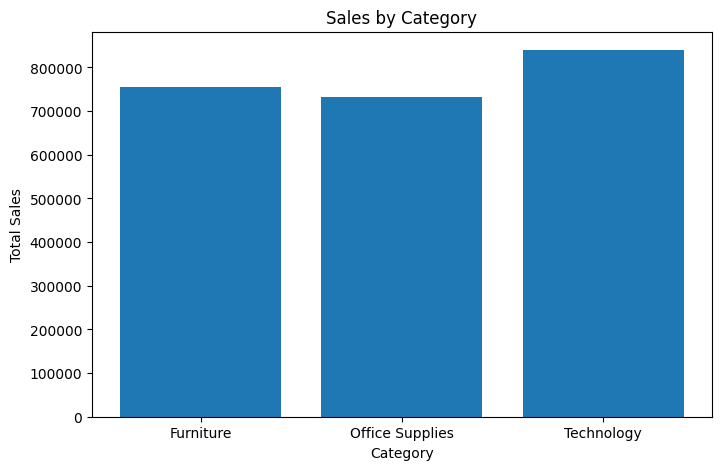

In [144]:
sales_by_category = (
    df.groupby('Category')['Sales']
      .sum()
      .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(
    sales_by_category['Category'],
    sales_by_category['Sales']
)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.title('Sales by Category')
plt.show()

25. Create a line chart in Matplotlib showing monthly Sales over time.

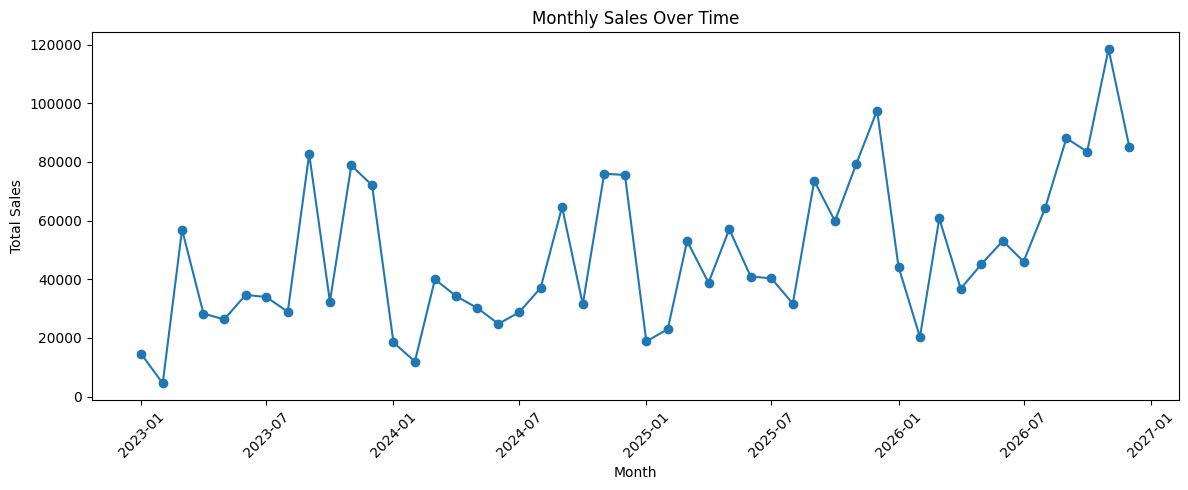

In [145]:
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
      .sum()
      .reset_index()
)

monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()